In [1]:
# ==========================================================
# 1. Import
# ==========================================================

import warnings

import matplotlib.pyplot as plt
import pandas as pd

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

In [2]:
# ==========================================================
# 2. Load Data
# ==========================================================

DATA_PATH = r"D:\Subject\CV2026\Market Risk Classification\market-risk-classification\data\processed\BTCUSDT\BTCUSDT_1m_clean.csv"

df = pd.read_csv(DATA_PATH)

df["open_time"] = pd.to_datetime(df["open_time"])
df["close_time"] = pd.to_datetime(df["close_time"])

print(df.shape)

df.head()

(20161, 12)


,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_volume,taker_buy_quote_volume,ignore
0,2025-01-01 00:00:00,93576.00,93610.93,93537.50,93610.93,8.21827,2025-01-01 00:00:59.999,7.689788e+05,2631,3.95157,369757.326529,0
1,2025-01-01 00:01:00,93610.93,93652.00,93606.20,93652.00,12.14029,2025-01-01 00:01:59.999,1.136551e+06,1273,4.08887,382791.500172,0
2,2025-01-01 00:02:00,93652.00,93702.15,93635.98,93702.15,11.60597,2025-01-01 00:02:59.999,1.087101e+06,1095,5.86840,549682.868570,0
3,2025-01-01 00:03:00,93702.14,93702.15,93654.48,93677.98,8.72958,2025-01-01 00:03:59.999,8.177203e+05,1461,2.48203,232486.113080,0
4,2025-01-01 00:04:00,93677.98,93677.99,93659.92,93661.20,5.24749,2025-01-01 00:04:59.999,4.915570e+05,988,0.48880,45786.251963,0


In [3]:
# ==========================================================
# 3. Dataset Overview
# ==========================================================

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20161 entries, 0 to 20160
Data columns (total 12 columns):
 #   Column                  Non-Null Count  Dtype         
---  ------                  --------------  -----         
 0   open_time               20161 non-null  datetime64[ns]
 1   open                    20161 non-null  float64       
 2   high                    20161 non-null  float64       
 3   low                     20161 non-null  float64       
 4   close                   20161 non-null  float64       
 5   volume                  20161 non-null  float64       
 6   close_time              20161 non-null  datetime64[ns]
 7   quote_asset_volume      20161 non-null  float64       
 8   number_of_trades        20161 non-null  int64         
 9   taker_buy_base_volume   20161 non-null  float64       
 10  taker_buy_quote_volume  20161 non-null  float64       
 11  ignore                  20161 non-null  int64         
dtypes: datetime64[ns](2), float64(8), int64(2)
mem

In [4]:
# ==========================================================
# 4. Missing Values
# ==========================================================

df.isnull().sum()

open_time                 0
open                      0
high                      0
low                       0
close                     0
volume                    0
close_time                0
quote_asset_volume        0
number_of_trades          0
taker_buy_base_volume     0
taker_buy_quote_volume    0
ignore                    0
dtype: int64

In [5]:
# ==========================================================
# 5. Statistical Summary
# ==========================================================

df.describe().T

,count,mean,min,25%,50%,75%,max,std
open_time,20161,2025-01-08 00:00:00,2025-01-01 00:00:00,2025-01-04 12:00:00,2025-01-08 00:00:00,2025-01-11 12:00:00,2025-01-15 00:00:00,NaN
open,20161.0,96061.08988,89417.87,94305.36,95410.19,97858.92,102687.21,2443.307941
high,20161.0,96091.742495,90172.49,94333.33,95452.93,97875.25,102724.38,2437.050914
low,20161.0,96030.945234,89256.69,94280.0,95360.91,97843.1,102490.0,2449.180125
close,20161.0,96061.235094,89417.88,94305.59,95410.97,97858.93,102687.21,2443.251333
volume,20161.0,15.270826,0.193,3.70555,7.72358,16.70647,771.79585,26.560273
close_time,20161,2025-01-08 00:00:59.999000064,2025-01-01 00:00:59.999000,2025-01-04 12:00:59.999000064,2025-01-08 00:00:59.999000064,2025-01-11 12:00:59.999000064,2025-01-15 00:00:59.999000,NaN
quote_asset_volume,20161.0,1460212.921793,18254.711294,357173.067443,743204.772355,1602298.4896,72461851.667273,2520508.261239
number_of_trades,20161.0,2464.094192,78.0,823.0,1587.0,3252.0,41159.0,2576.134257
taker_buy_base_volume,20161.0,7.302997,0.0333,1.35864,3.39136,8.01546,355.07788,13.227579


In [6]:
# ==========================================================
# 6. Duplicate Rows
# ==========================================================

print(df.duplicated().sum())

0


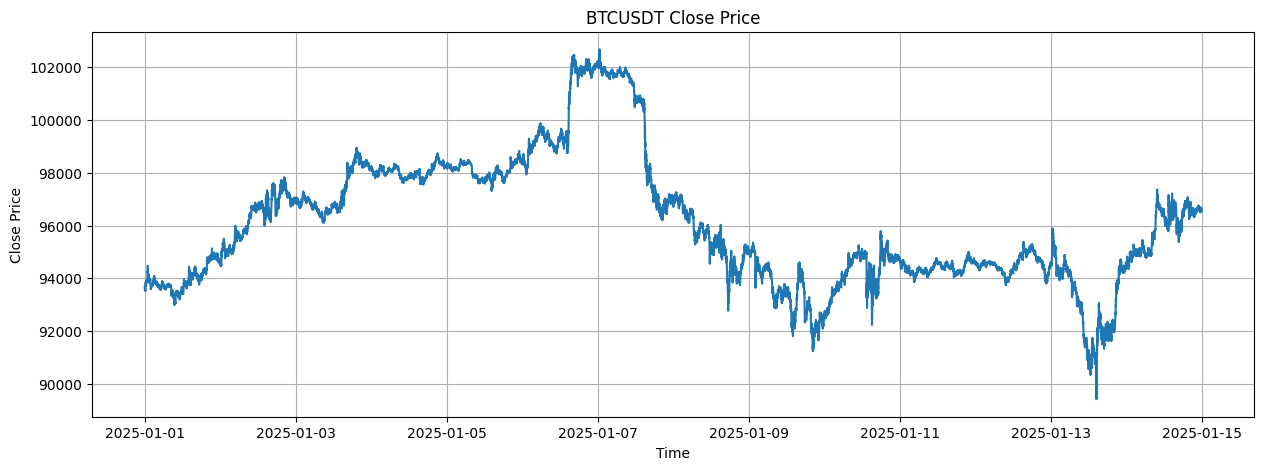

In [7]:
# ==========================================================
# 7. Price Trend
# ==========================================================

plt.figure(figsize=(15,5))

plt.plot(df["open_time"], df["close"])

plt.title("BTCUSDT Close Price")

plt.xlabel("Time")

plt.ylabel("Close Price")

plt.grid()

plt.show()

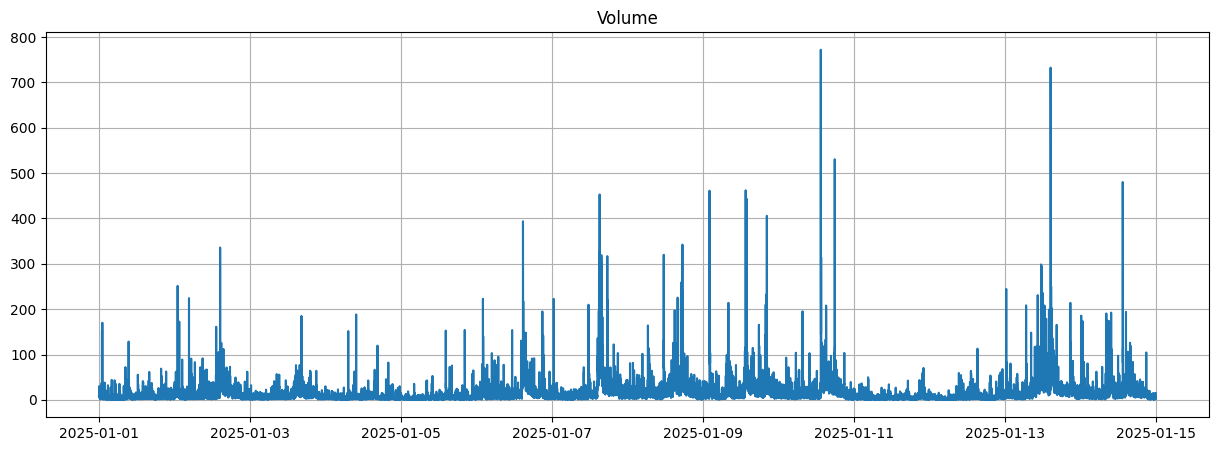

In [8]:
# ==========================================================
# 8. Volume
# ==========================================================

plt.figure(figsize=(15,5))

plt.plot(df["open_time"], df["volume"])

plt.title("Volume")

plt.grid()

plt.show()

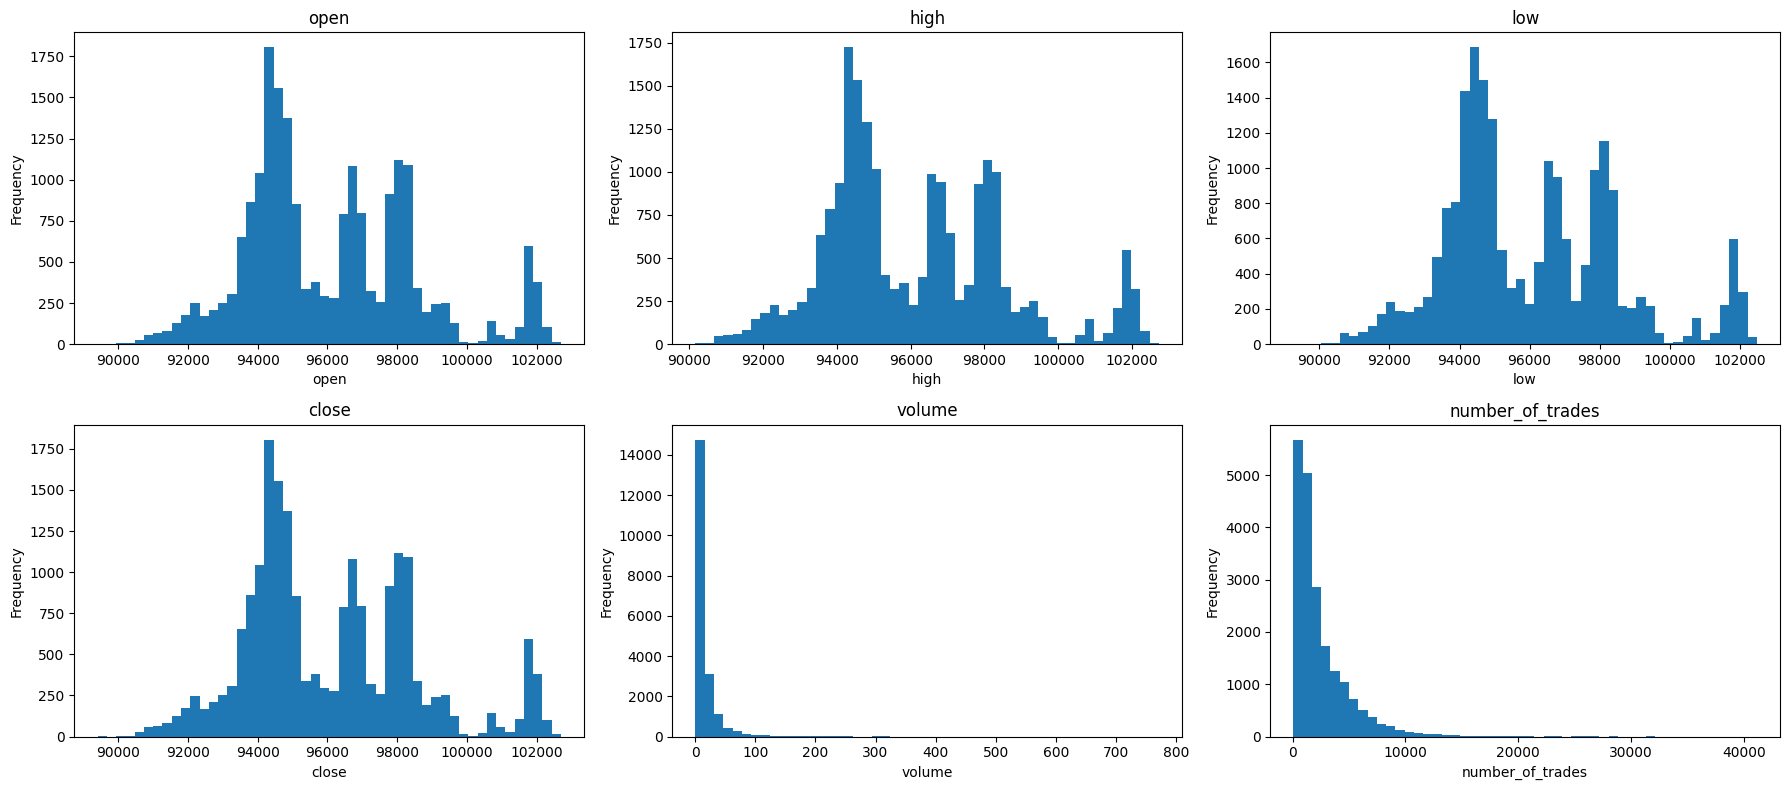

In [16]:
# ========================================================== 
# 9. Distribution
# ========================================================== 

import matplotlib.pyplot as plt

numeric_cols = [
    "open",
    "high",
    "low",
    "close",
    "volume",
    "number_of_trades"
]

fig, axes = plt.subplots(2, 3, figsize=(18, 8))

axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=50)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [10]:
# ==========================================================
# 10. Correlation
# ==========================================================

corr = df[
    [
        "open",
        "high",
        "low",
        "close",
        "volume",
        "number_of_trades",
        "quote_asset_volume",
    ]
].corr()

corr

,open,high,low,close,volume,number_of_trades,quote_asset_volume
open,1.000000,0.999821,0.999825,0.999690,-0.102872,-0.165796,-0.084870
high,0.999821,1.000000,0.999695,0.999835,-0.094291,-0.155448,-0.076225
low,0.999825,0.999695,1.000000,0.999838,-0.112682,-0.176499,-0.094688
close,0.999690,0.999835,0.999838,1.000000,-0.104203,-0.166306,-0.086149
volume,-0.102872,-0.094291,-0.112682,-0.104203,1.000000,0.799650,0.999301
number_of_trades,-0.165796,-0.155448,-0.176499,-0.166306,0.799650,1.000000,0.800684
quote_asset_volume,-0.084870,-0.076225,-0.094688,-0.086149,0.999301,0.800684,1.000000


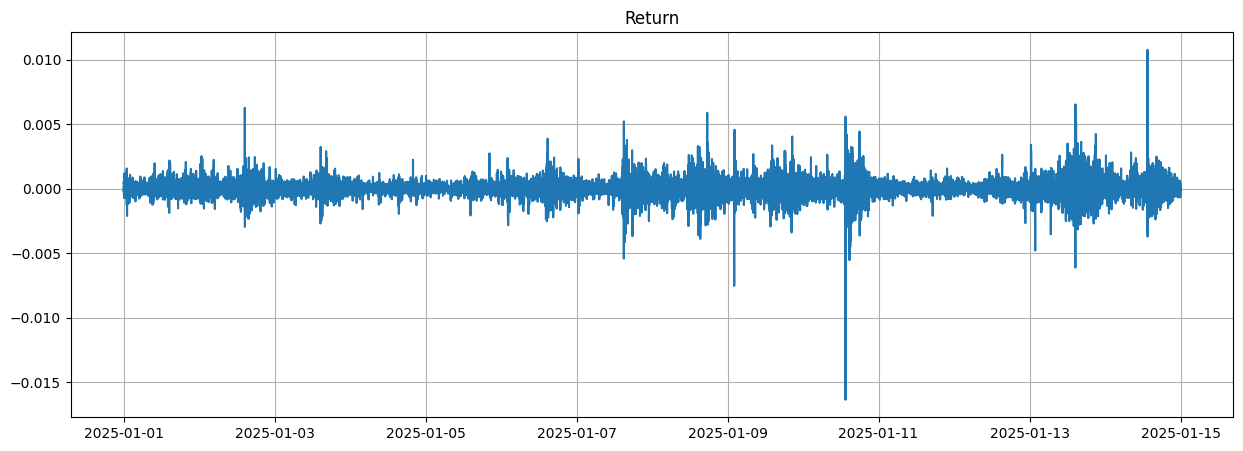

In [11]:
# ==========================================================
# 11. Price Return
# ==========================================================

df["return"] = df["close"].pct_change()

plt.figure(figsize=(15,5))

plt.plot(df["open_time"], df["return"])

plt.title("Return")

plt.grid()

plt.show()

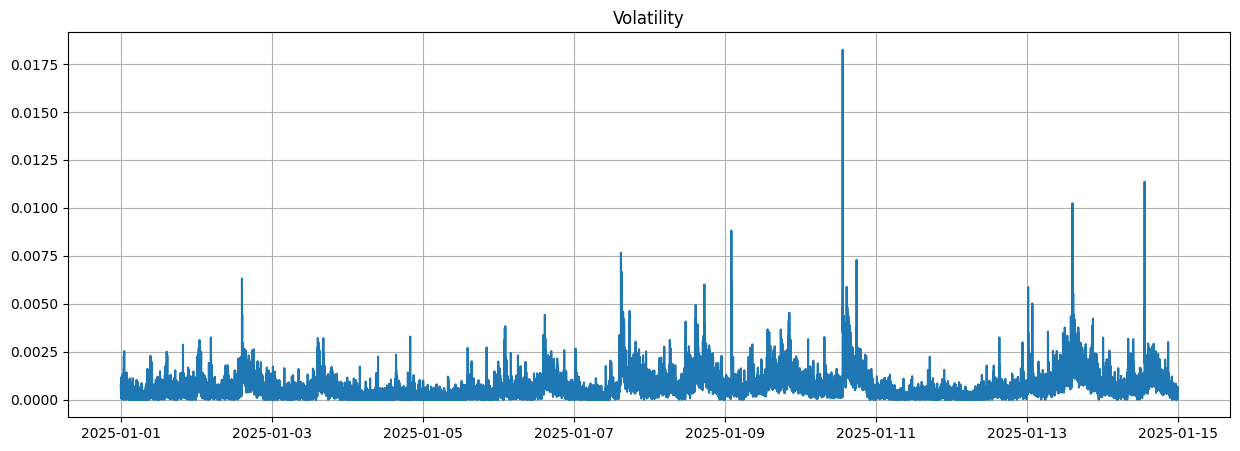

In [12]:
# ==========================================================
# 12. Volatility
# ==========================================================

df["volatility"] = (
    df["high"] - df["low"]
) / df["close"]

plt.figure(figsize=(15,5))

plt.plot(
    df["open_time"],
    df["volatility"]
)

plt.title("Volatility")

plt.grid()

plt.show()

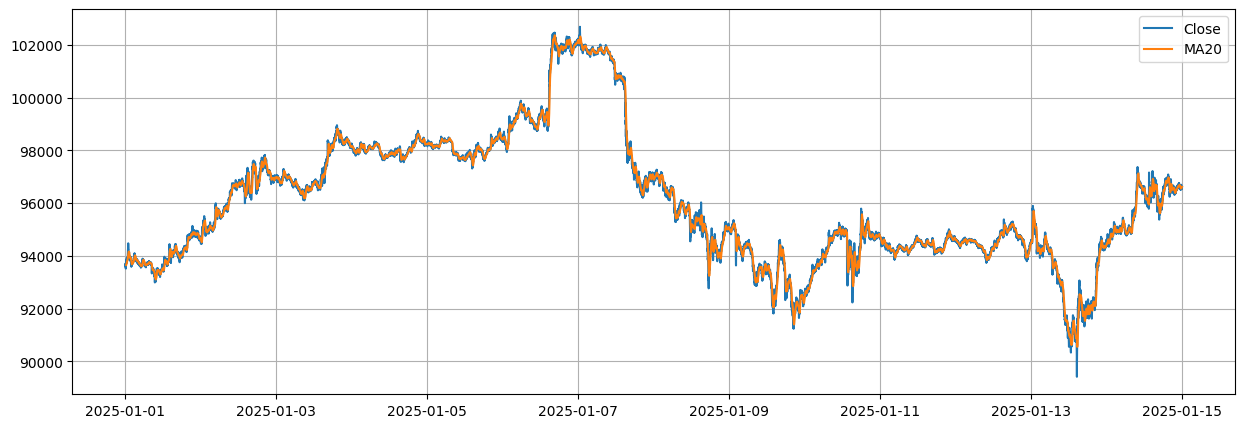

In [13]:
# ==========================================================
# 13. Rolling Statistics
# ==========================================================

df["ma20"] = df["close"].rolling(20).mean()

plt.figure(figsize=(15,5))

plt.plot(df["open_time"], df["close"], label="Close")

plt.plot(df["open_time"], df["ma20"], label="MA20")

plt.legend()

plt.grid()

plt.show()

In [14]:
# ==========================================================
# 14. Top Volume
# ==========================================================

df.nlargest(
    20,
    "volume"
)[
    [
        "open_time",
        "close",
        "volume"
    ]
]

,open_time,close,volume
13770,2025-01-10 13:30:00,93267.23,771.79585
18154,2025-01-13 14:34:00,89968.00,732.27909
18155,2025-01-13 14:35:00,89417.88,616.84305
14036,2025-01-10 17:56:00,95532.99,530.39058
19530,2025-01-14 13:30:00,96930.00,480.28580
12337,2025-01-09 13:37:00,92408.02,461.97942
11647,2025-01-09 02:07:00,93896.00,461.13854
9551,2025-01-07 15:11:00,98521.49,452.79018
12353,2025-01-09 13:53:00,92047.93,443.72091
12741,2025-01-09 20:21:00,91365.63,405.65257


In [15]:
# ==========================================================
# 15. Save EDA Dataset
# ==========================================================

df.head()

,open_time,open,high,low,close,volume,close_time,quote_asset_volume,number_of_trades,taker_buy_base_volume,taker_buy_quote_volume,ignore,return,volatility,ma20
0,2025-01-01 00:00:00,93576.00,93610.93,93537.50,93610.93,8.21827,2025-01-01 00:00:59.999,7.689788e+05,2631,3.95157,369757.326529,0,NaN,0.000784,NaN
1,2025-01-01 00:01:00,93610.93,93652.00,93606.20,93652.00,12.14029,2025-01-01 00:01:59.999,1.136551e+06,1273,4.08887,382791.500172,0,0.000439,0.000489,NaN
2,2025-01-01 00:02:00,93652.00,93702.15,93635.98,93702.15,11.60597,2025-01-01 00:02:59.999,1.087101e+06,1095,5.86840,549682.868570,0,0.000535,0.000706,NaN
3,2025-01-01 00:03:00,93702.14,93702.15,93654.48,93677.98,8.72958,2025-01-01 00:03:59.999,8.177203e+05,1461,2.48203,232486.113080,0,-0.000258,0.000509,NaN
4,2025-01-01 00:04:00,93677.98,93677.99,93659.92,93661.20,5.24749,2025-01-01 00:04:59.999,4.915570e+05,988,0.48880,45786.251963,0,-0.000179,0.000193,NaN
